In [1]:
import numpy as np
import pandas as pd
import scanpy as sc 

np.random.seed(42) 

adata = sc.read_h5ad("dataset_co_mo2.h5ad")
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)

In [31]:
adata.var_names

Index(['LINC01409', 'LINC01128', 'LINC00115', 'FAM41C', 'SAMD11', 'NOC2L',
       'KLHL17', 'PLEKHN1', 'HES4', 'ISG15',
       ...
       'FUNDC2', 'CMC4', 'MTCP1', 'BRCC3', 'VBP1', 'TMLHE', 'SPRY3', 'VAMP7',
       'IL6RorST', 'TGFBR1or2'],
      dtype='object', length=13125)

In [ ]:
#gl_ct1 = ['STAT3','IL6RorST','TGFBR1or2','PDGFB'] # All values from the first column
#gl_ct1 =['PDGFRB', 'TGFB1', 'IL6']  # All values from the second column
#gl_ct2 = ['PDGFB', 'STAT3','TGFBR1','TGFBR2','IL6R', 'IL6ST'] # All values from the first column

gl_ct1 =['PDGFB', 'STAT3', 'HES4', 'TGFB1']  # All values from the second column
gl_ct2 = ['PDGFRB','TGFBR1','TGFBR2'] # All values from the first column
# q0 -> PDGFB
# q1 -> STAT3
# q2 -> HIF1A
# q3 -> TGFB1
# q4 -> PDGFRB
# q5 -> TGFBR1
# q6 -> TGFBR2
gl_all = gl_ct1 + gl_ct2

In [3]:
from scipy.sparse import issparse

ict1 = adata.obs["BatchID"] == "Cancer Cells (Co)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Co)" 

adata_ct1_co = adata[ict1, gl_ct1]
adata_ct2_co = adata[ict2, gl_ct2]
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_ct1, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_ct2, knn=5, random_state=42) 

print(adata_ct1_co)
print(adata_ct2_co)

if issparse(adata_ct1_co.X):
    Xct1_co = adata_ct1_co.X.toarray()
else:
    Xct1_co = adata_ct1_co.X

if issparse(adata_ct2_co.X):
    Xct2_co = adata_ct2_co.X.toarray()
else:
    Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 1414 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 1324 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
CT1 (Co) mean expression: [0. 0. 0. 0.]
CT2 (Co) mean expression: [0. 0. 0.]


In [4]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Mo)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Mo)" 

adata_ct1_mo = adata[ict1, gl_ct1]
adata_ct2_mo = adata[ict2, gl_ct2]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_ct1, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_ct2, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

if issparse(adata_ct1_mo.X):
    Xct1_mo = adata_ct1_mo.X.toarray()
else:
    Xct1_mo = adata_ct1_mo.X

if issparse(adata_ct2_mo.X):
    Xct2_mo = adata_ct2_mo.X.toarray()
else:
    Xct2_mo = adata_ct2_mo.X

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 2364 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 2788 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'


In [5]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documentos\vscode_working_dir\QuantumXCT\python\cc_grn_functions"

sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

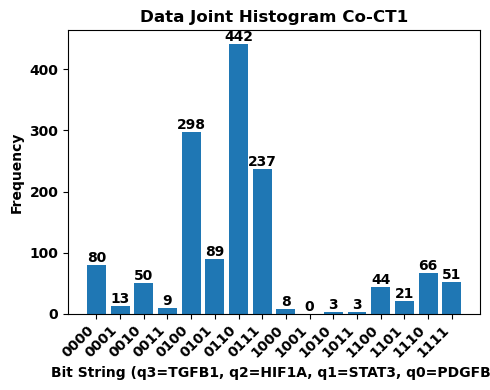

Joint Counts: Counter({'0110': 442, '0100': 298, '0111': 237, '0101': 89, '0000': 80, '1110': 66, '1111': 51, '0010': 50, '1100': 44, '1101': 21, '0001': 13, '0011': 9, '1000': 8, '1010': 3, '1011': 3})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1010', '1011', '1100', '1101', '1110', '1111']


In [6]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
#joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1] 
plot_joint_histogram(joint_counts_ct1_co, num_qubits = num_qubits, features=gl_ct1, figsize = (5,4), 
                     #filename = 'co_ct1_ov_can_hist_dist.svg',
                     title='Data Joint Histogram Co-CT1' )  # Pass num_qubits
#plot_joint_histogram(histogram_data, figsize=(5,4), filename = 'hist_cc_3_4pi.svg', title= r'Histogram $Ry(3\pi/4)$' )

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

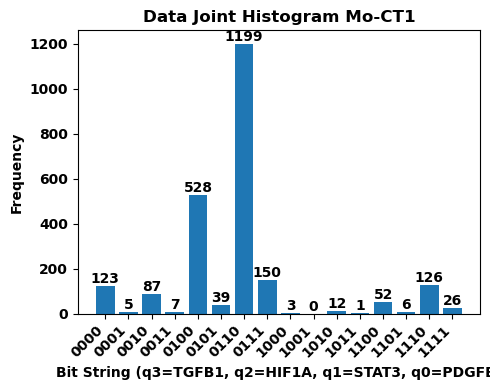

Joint Counts: Counter({'0110': 1199, '0100': 528, '0111': 150, '1110': 126, '0000': 123, '0010': 87, '1100': 52, '0101': 39, '1111': 26, '1010': 12, '0011': 7, '1101': 6, '0001': 5, '1000': 3, '1011': 1})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1010', '1011', '1100', '1101', '1110', '1111']


In [7]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits = num_qubits, features=gl_ct1, figsize = (5,4),
                     #filename = 'mo_ct1_ov_can_hist_dist.svg', 
                     title='Data Joint Histogram Mo-CT1' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

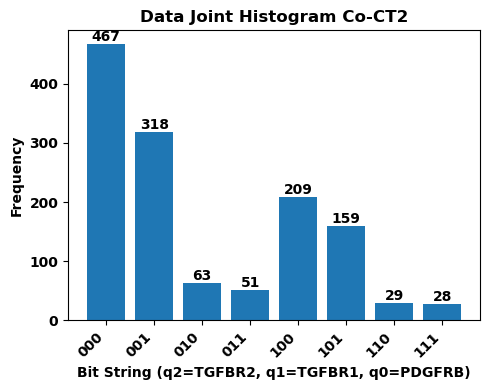

Joint Counts: Counter({'000': 467, '001': 318, '100': 209, '101': 159, '010': 63, '011': 51, '110': 29, '111': 28})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [8]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
#joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits = num_qubits2, features=gl_ct2, figsize = (5,4), 
                     #filename = 'co_ct2_ov_can_hist_dist.svg', 
                     title='Data Joint Histogram Co-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

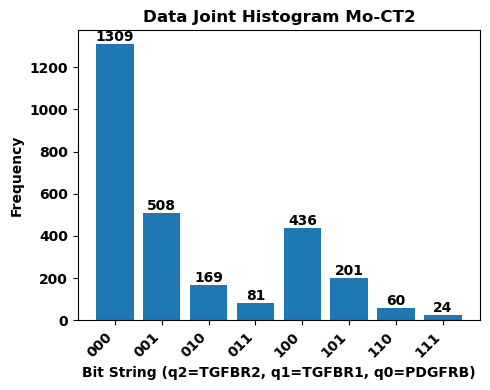

Joint Counts: Counter({'000': 1309, '001': 508, '100': 436, '101': 201, '010': 169, '011': 81, '110': 60, '111': 24})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [9]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits = num_qubits2, features=gl_ct2, figsize = (5,4), 
                     #filename = 'mo_ct1_ov_can_hist_dist.svg', 
                     title='Data Joint Histogram Mo-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [10]:
from quantum_functions import vector_normalize_dictionary_values, create_initial_circuit2

# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set CT1 MO:", joint_counts_ct1_mo)
print("State Set CT2 MO:", joint_counts_ct2_mo)
print("Interacted State Set CT1 CO:", joint_counts_ct1_co)
print("Interacted State Set CT2 CO:", joint_counts_ct2_co)

# Apply vector normalization to the new dictionaries
normalized_joint_counts_ct1_mo = vector_normalize_dictionary_values(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = vector_normalize_dictionary_values(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = vector_normalize_dictionary_values(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = vector_normalize_dictionary_values(joint_counts_ct2_co)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set CT1 MO (Vector Norm):", normalized_joint_counts_ct1_mo)
print("Normalized State Set CT2 MO (Vector Norm):", normalized_joint_counts_ct2_mo)
print("Normalized Interacted State Set CT1 CO (Vector Norm):", normalized_joint_counts_ct1_co)
print("Normalized Interacted State Set CT2 CO (Vector Norm):", normalized_joint_counts_ct2_co)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_joint_counts_ct1_mo)
circ2 = create_initial_circuit2(normalized_joint_counts_ct2_mo)

--- New Dictionary Definitions ---
State Set CT1 MO: Counter({'0110': 1199, '0100': 528, '0111': 150, '1110': 126, '0000': 123, '0010': 87, '1100': 52, '0101': 39, '1111': 26, '1010': 12, '0011': 7, '1101': 6, '0001': 5, '1000': 3, '1011': 1})
State Set CT2 MO: Counter({'000': 1309, '001': 508, '100': 436, '101': 201, '010': 169, '011': 81, '110': 60, '111': 24})
Interacted State Set CT1 CO: Counter({'0110': 442, '0100': 298, '0111': 237, '0101': 89, '0000': 80, '1110': 66, '1111': 51, '0010': 50, '1100': 44, '1101': 21, '0001': 13, '0011': 9, '1000': 8, '1010': 3, '1011': 3})
Interacted State Set CT2 CO: Counter({'000': 467, '001': 318, '100': 209, '101': 159, '010': 63, '011': 51, '110': 29, '111': 28})

--- Vector Normalized Dictionary Definitions ---
Normalized State Set CT1 MO (Vector Norm): {'0100': 0.395461353013933, '0110': 0.8980268224691395, '0000': 0.0921245197362003, '0111': 0.11234697528804914, '1100': 0.03894695143319037, '1110': 0.09437145924196128, '0010': 0.06516124566

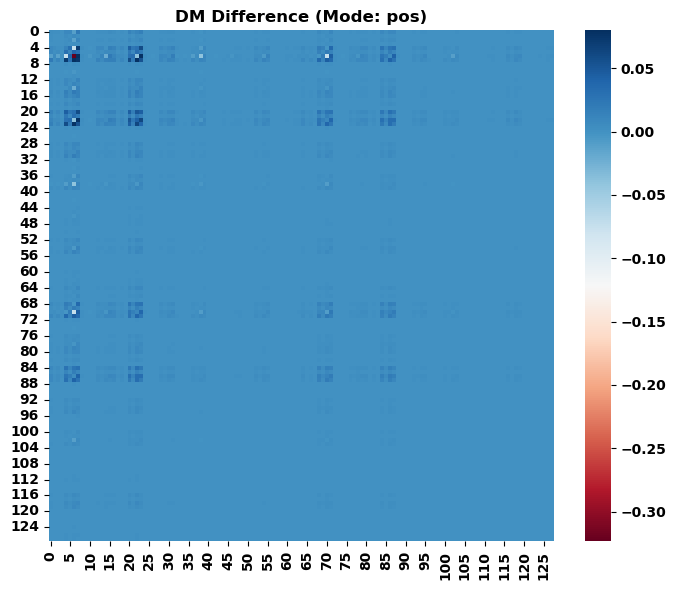


--- CNOT Analysis (pos) ---
Max Signal: 0.0800
Candidates Found: 24 / 42
------------------------------

{'max_element': 0.07999539816290704, 'min_element': -0.32348906402760175, 'abs_average': 0.000936254386358833, 'relevant_avg': 0.0010212670681044621}


In [12]:
from quantum_functions import find_cnot_candidates_from_state_diff

thresh = 0.02 # 0.02
# --- State and Density Matrix Analysis ---
initial_cnot_config, stats = find_cnot_candidates_from_state_diff(
    normalized_joint_counts_ct1_mo, normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co,
    threshold = thresh, show_plot = True, search_mode="pos" , 
    verbose_print = True)

print(stats)


--- Running N-wise Search ---

--- Starting Iterative Pairwise Search ---


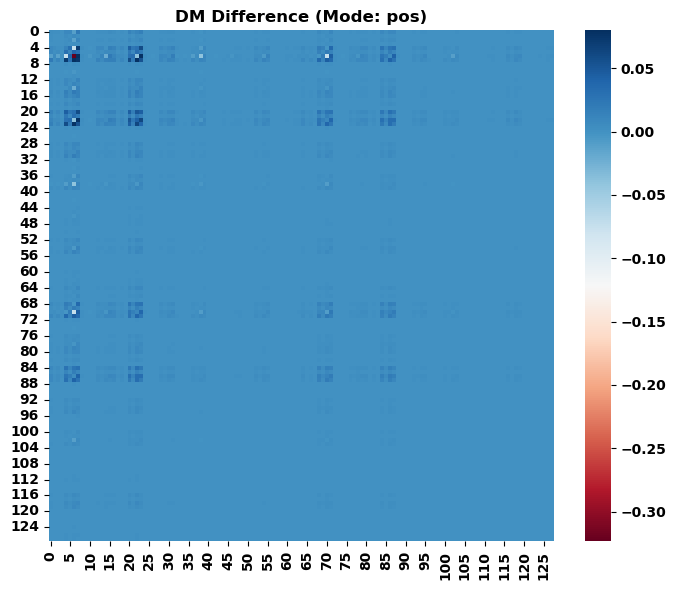


--- CNOT Analysis (pos) ---
Max Signal: 0.0800
Candidates Found: 24 / 42
------------------------------

Number of initial CNOT candidates: 24
Initial KL-divergence: 0.332089

  - Starting Efficiency-Optimized Search -

--- Iteration 1 | Current KL: 0.324206 ---
   - Single Insertion Phase: Added (4, 0) at index 0. New KL: 0.216651
  [Phase 1] Added Single: (4, 0) | New KL: 0.216651
  [Phase 2] Added Pair: ((0, 4), (1, 4)) | New KL: 0.159969

--- Iteration 2 | Current KL: 0.159969 ---
   - Single Insertion Phase: Added (4, 1) at index 3. New KL: 0.095511
  [Phase 1] Added Single: (4, 1) | New KL: 0.095511

--- Iteration 3 | Current KL: 0.095511 ---
  - No improvements in any phase. Search Terminated.

--- Total Search Time: 309.20s ---

--- Pairwise Addition Result ---
Best sequence after addition: [(4, 0), (0, 4), (1, 4), (4, 1)]
KL sum after addition: 0.095511

Total search time: 309.68 seconds.

Multi-Epoch Search Optimal CNOT sequence found:
  q[4] -> q[0]
  q[0] -> q[4]
  q[1] ->

In [13]:
from quantum_functions import find_best_cnot_sequence_iterative_n_wise, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit

np.random.seed(42) 

print("\n" + "="*40)
print("--- Running N-wise Search ---")
print("="*40)

all_possible_single_cnots, best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_iterative_n_wise(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh,
    search_mode= "pos",
    nchoose=2,
    kl_tol = 0.05
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'0110': 3057, '0111': 339, '0100': 1414, '1110': 42, '0101': 64, '0000': 33, '0011': 7, '1100': 14, '0010': 25, '0001': 2, '1111': 2, '1010': 1}
Counts for c_measure2: {'000': 2451, '001': 1934, '010': 41, '100': 291, '101': 229, '011': 46, '111': 1, '110': 7}


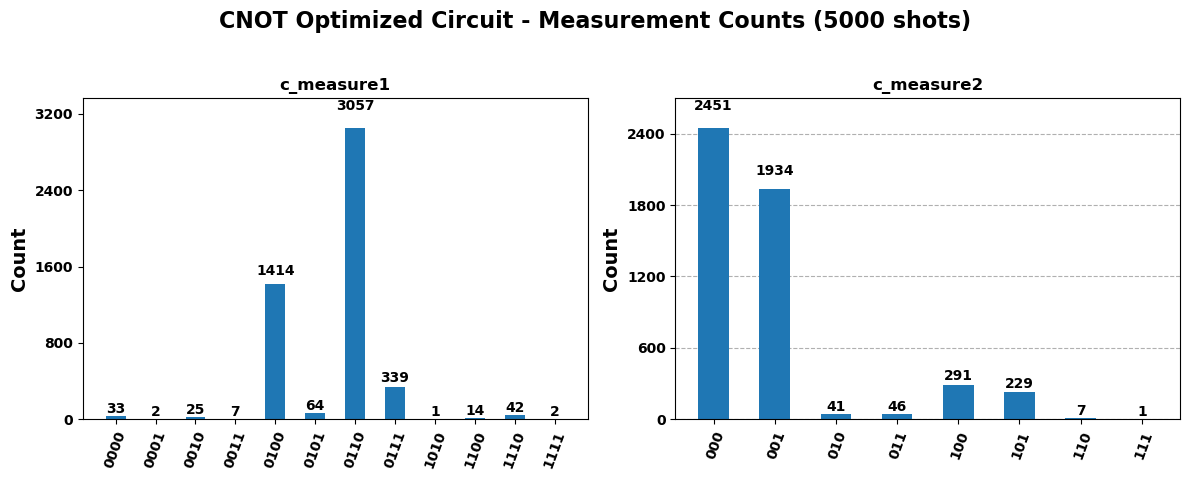

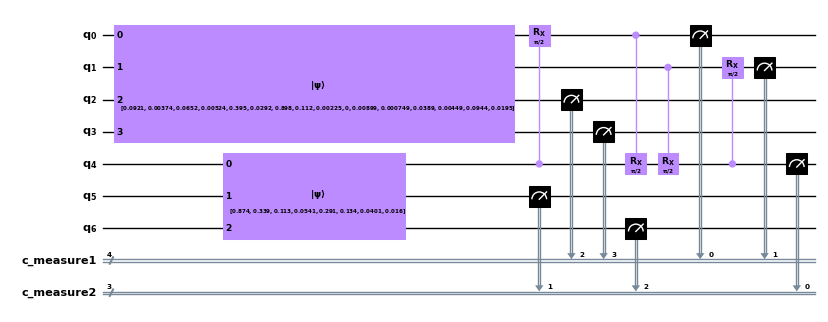

In [19]:
from quantum_functions import plot_measurement_histograms

measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5 )

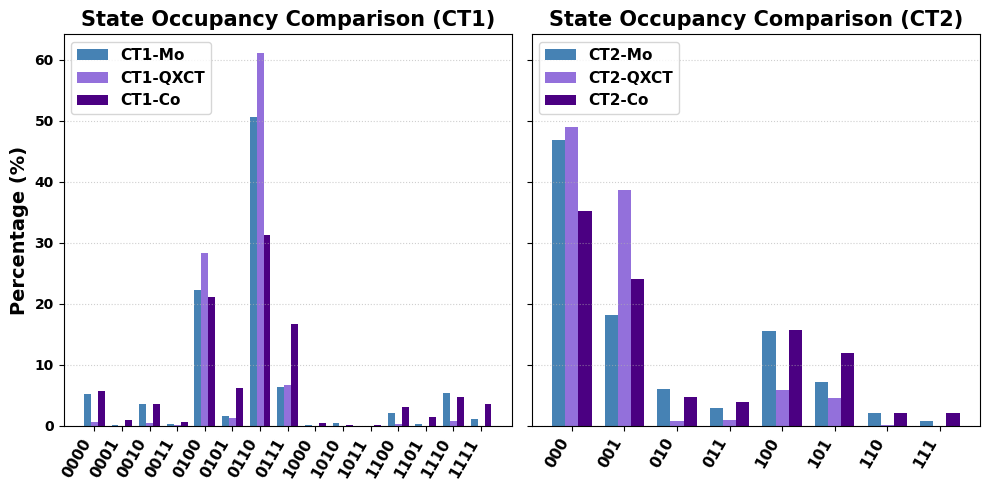

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (4 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['3.1096', '1.5290', '1.4016', '1.2706']
CRX Angle Optimization took: 13.21 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['3.1096', '1.5290', '1.4016', '1.2706']
  Minimum Combined KL Divergence with Optimized CRX: 0.038745


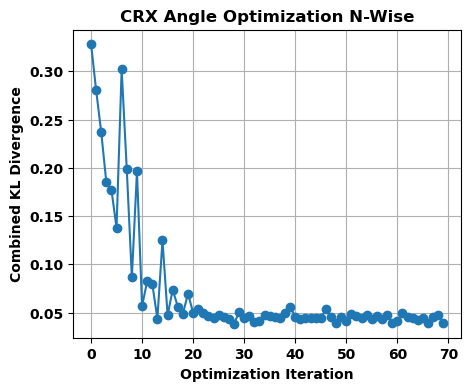


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                         ├»
«              │                                                                                                                                                          │»
«         q_1: ┤1                                                                                                                  

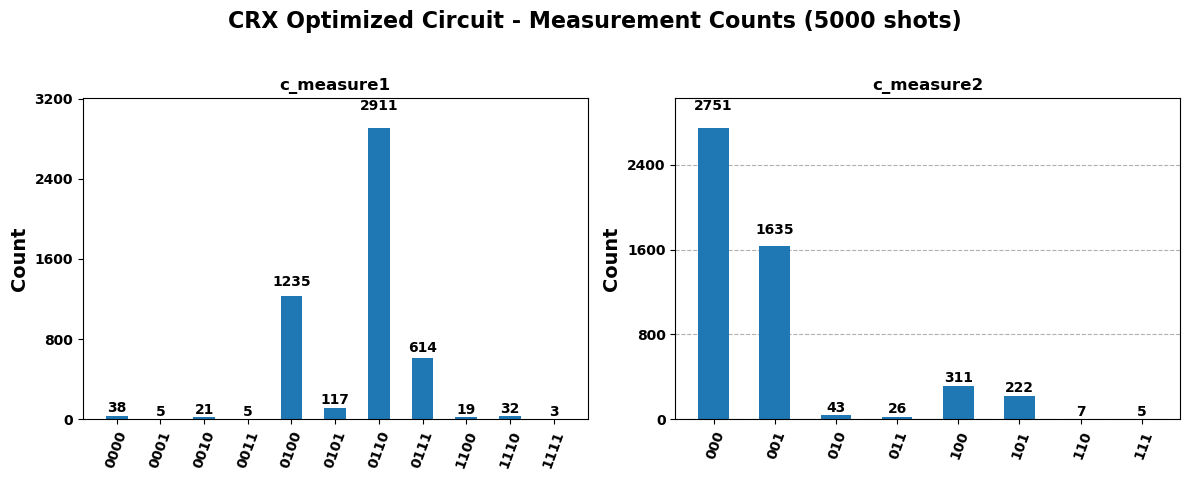

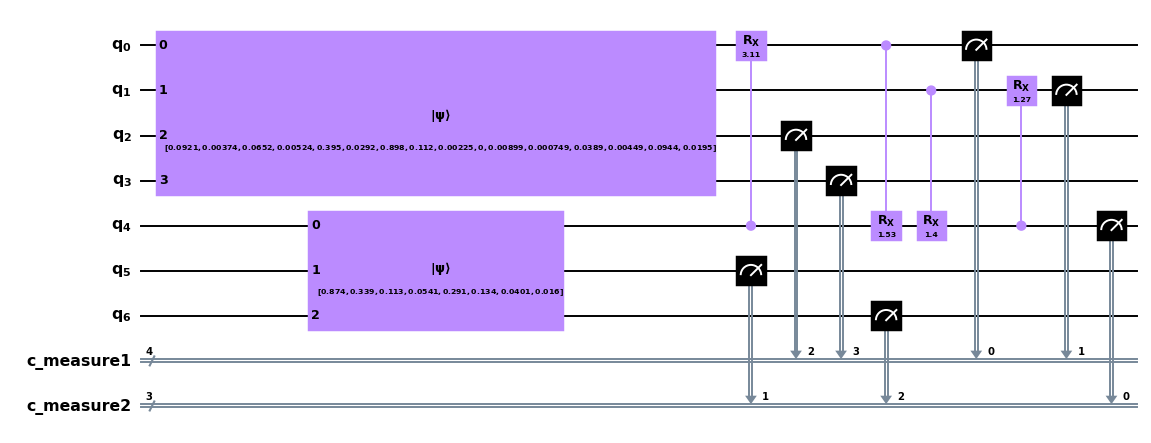

In [21]:
from quantum_functions import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*0/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(5, 4))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization N-Wise')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    plt.savefig('optimization_history_sim_nwise_ov_can.svg', format='svg')
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.7, filename="optimized_circ_nwise_ov_can.svg")


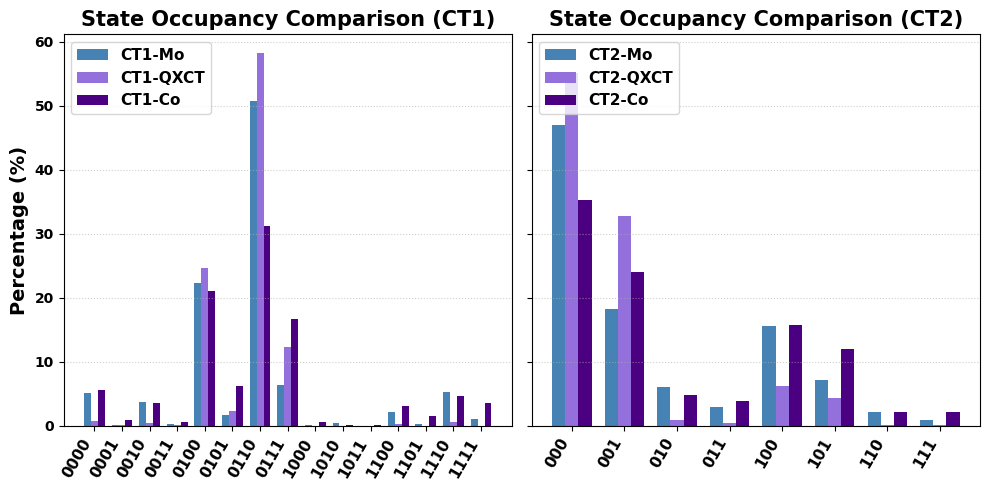

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('state_occupancy_comparison_ang_opt_nwise_hist_ov_can.svg')
plt.show()

In [23]:
from quantum_functions import summarize_interaction_network
# 2. Call the function and capture the returned objects
# (Assuming best_cnot_sequence and optimized_crx_angles are your result variables)
interaction_df, hub_dict, gene_set = summarize_interaction_network(
    topology=best_cnot_sequence,
    angles=optimized_crx_angles,
    gene_list=gl_all
)

# 3. Now you can work with the returned objects
print("\n--- DataFrame returned from function: ---")
print(interaction_df)


--- Interpreted Interaction Network Summary ---

--- Detailed Interaction List ---
   Control Qubit  Target Qubit Control Gene Target Gene      Interaction CRX Angle (rad) CRX Angle (deg)
0              4             0       PDGFRB       PDGFB  PDGFRB -> PDGFB          3.1096         178.17°
1              0             4        PDGFB      PDGFRB  PDGFB -> PDGFRB          1.5290          87.61°
2              1             4        STAT3      PDGFRB  STAT3 -> PDGFRB          1.4016          80.30°
3              4             1       PDGFRB       STAT3  PDGFRB -> STAT3          1.2706          72.80°

--- Hub-based Interaction Summary ---
Gene 'PDGFRB' interacts with: PDGFB, STAT3
Gene 'PDGFB' interacts with: PDGFRB
Gene 'STAT3' interacts with: PDGFRB

--- Full Set of Interacting Genes ---
['PDGFB', 'PDGFRB', 'STAT3']

--- DataFrame returned from function: ---
   Control Qubit  Target Qubit Control Gene Target Gene      Interaction  \
0              4             0       PDGFRB       


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---

--- Generating CNOT candidates from density matrix difference. ---


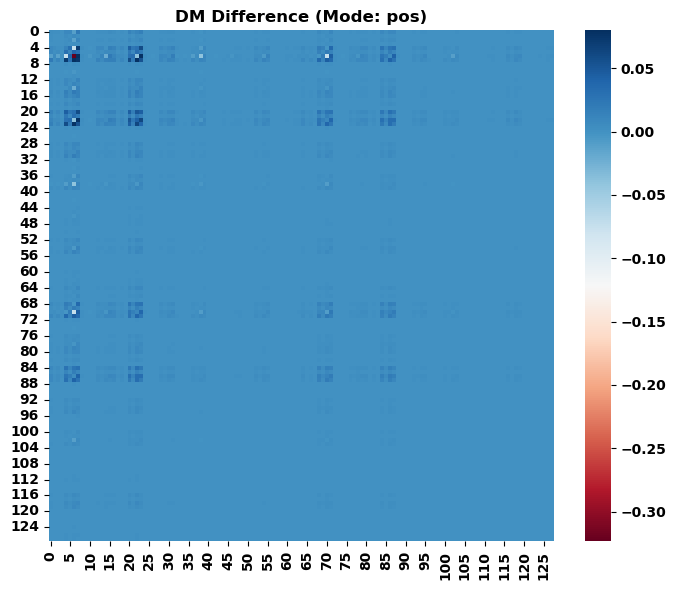


--- CNOT Analysis (pos) ---
Max Signal: 0.0800
Candidates Found: 24 / 42
------------------------------

Initial KL divergence (baseline): 0.339254

--- Starting Epoch 1/24 (Addition) with CNOT: (2, 6) (KL: 0.598523) ---
  Skipping epoch: Single CNOT KL (0.598523) does not improve over baseline (0.339254).

--- Starting Epoch 2/24 (Addition) with CNOT: (1, 2) (KL: 1.585306) ---
  Skipping epoch: Single CNOT KL (1.585306) does not improve over baseline (0.339254).

--- Starting Epoch 3/24 (Addition) with CNOT: (2, 3) (KL: 1.571635) ---
  Skipping epoch: Single CNOT KL (1.571635) does not improve over baseline (0.339254).

--- Starting Epoch 4/24 (Addition) with CNOT: (6, 2) (KL: 0.370307) ---
  Skipping epoch: Single CNOT KL (0.370307) does not improve over baseline (0.339254).

--- Starting Epoch 5/24 (Addition) with CNOT: (1, 3) (KL: 1.346091) ---
  Skipping epoch: Single CNOT KL (1.346091) does not improve over baseline (0.339254).

--- Starting Epoch 6/24 (Addition) with CNOT: (4, 

In [24]:
from quantum_functions import find_best_cnot_sequence_multi_epoch

np.random.seed(42) 

print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 50
min_greedy_depth = 20

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold=thresh,
    search_mode="pos",
    kl_tol = 0.05
)


print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'0100': 987, '0110': 2796, '0111': 877, '0101': 224, '1110': 29, '0010': 15, '1111': 8, '0000': 43, '0011': 9, '1100': 8, '0001': 1, '1101': 3}
Counts for c_measure2: {'000': 2801, '100': 324, '001': 1593, '101': 203, '010': 38, '011': 36, '110': 5}


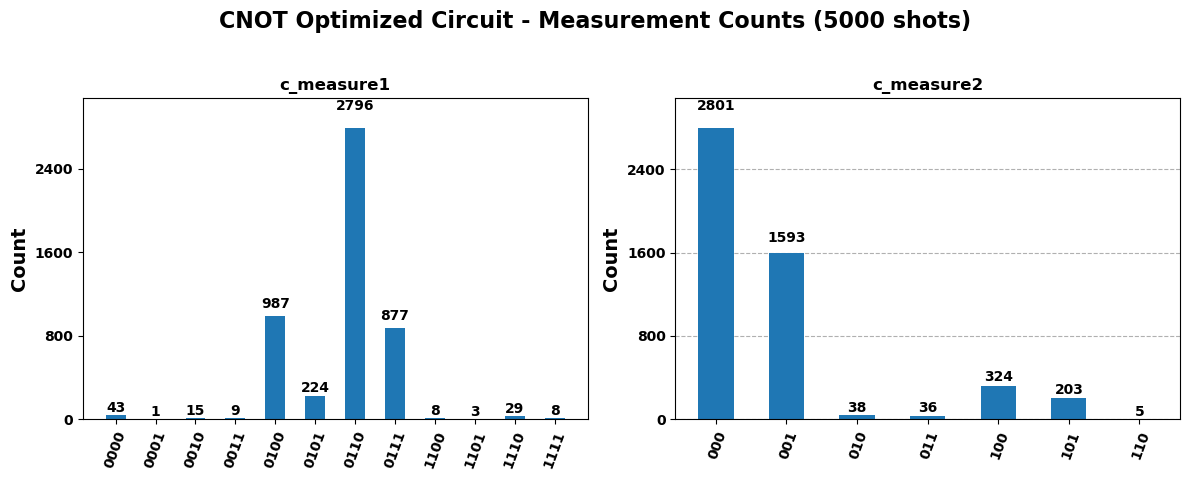

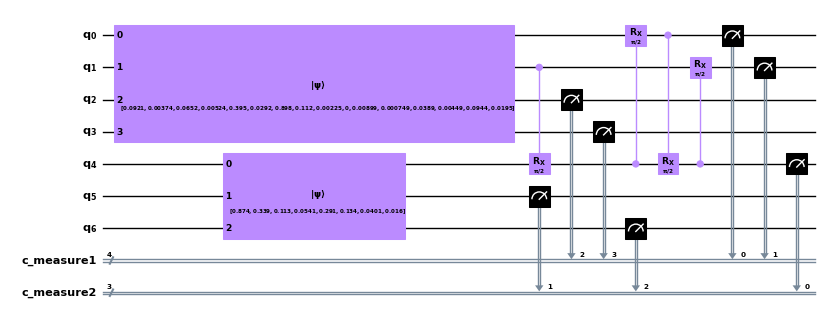

In [25]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

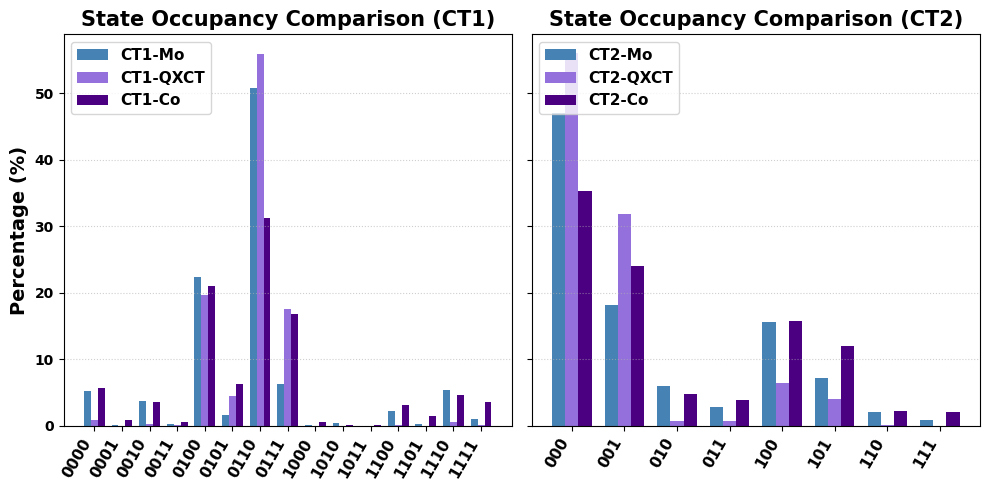

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison_multi_epoch_hist_ov_can.svg')
plt.show()


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (4 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['1.1477', '1.5855', '0.5600', '0.0000']
CRX Angle Optimization took: 15.02 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['1.1477', '1.5855', '0.5600', '0.0000']
  Minimum Combined KL Divergence with Optimized CRX: 0.072008


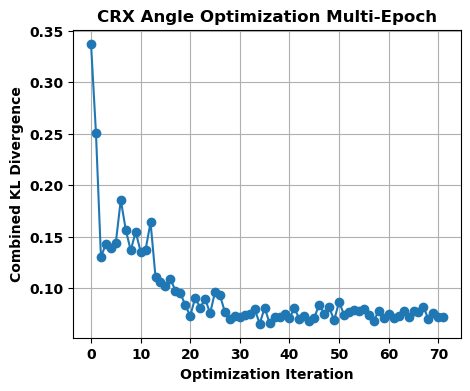


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                         ├»
«              │                                                                                                                                                          │»
«         q_1: ┤1                                                                                                                  

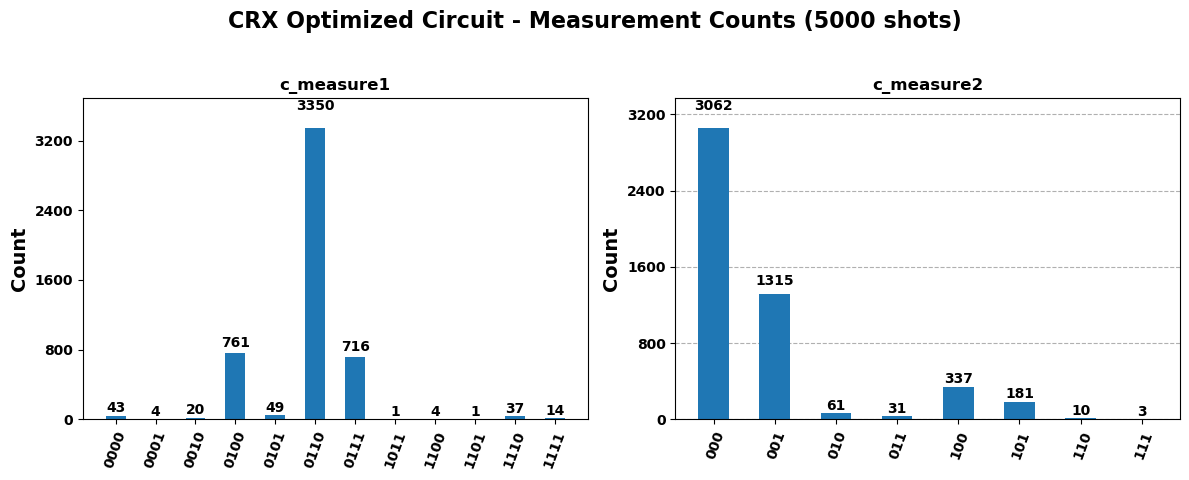

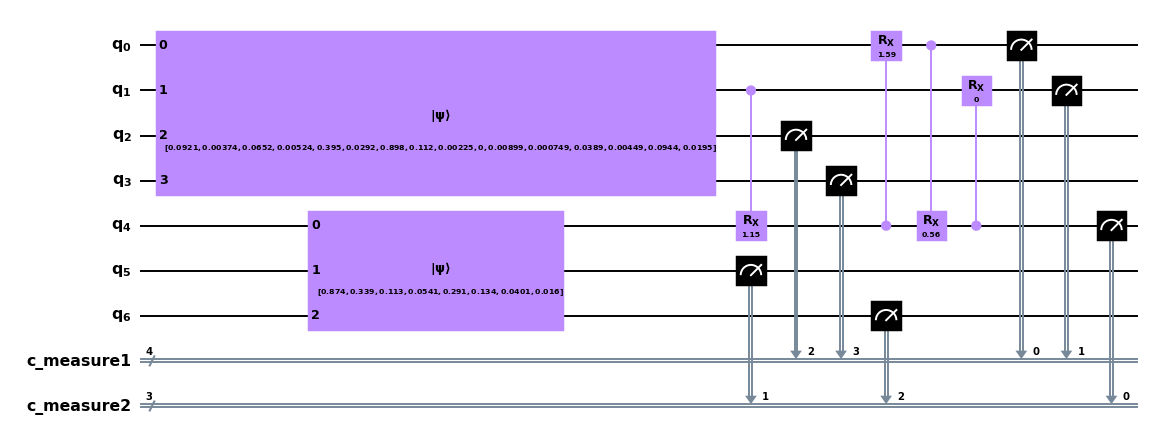

In [27]:
from quantum_functions import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*0/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(5, 4))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization Multi-Epoch')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    plt.savefig('optimization_history_sim_multi_epoch_ov_can.svg', format='svg')

    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.7, filename="optimized_circ_multi_epoch_ov_can.svg")


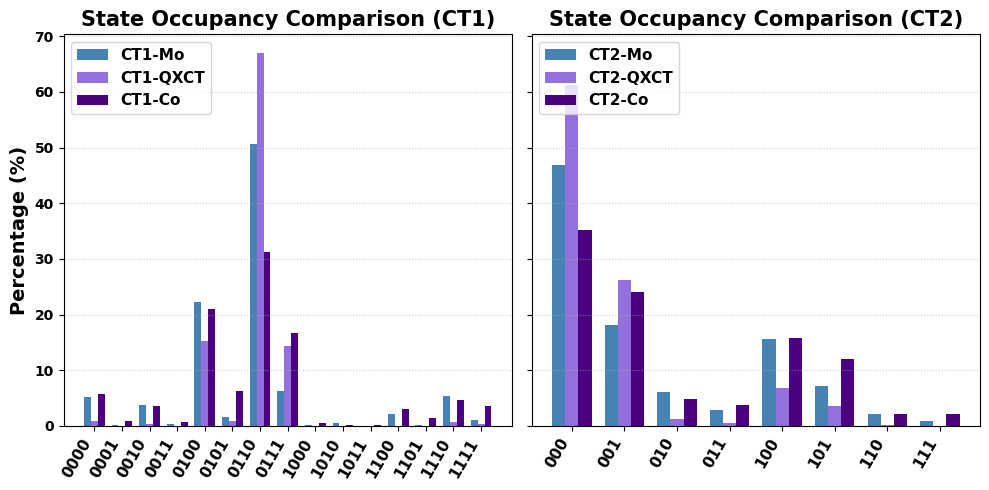

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('state_occupancy_comparison_ang_opt_multi_epoch_hist_ov_can.svg')
plt.show()

In [29]:
from quantum_functions import summarize_interaction_network
# 2. Call the function and capture the returned objects
# (Assuming best_cnot_sequence and optimized_crx_angles are your result variables)
interaction_df, hub_dict, gene_set = summarize_interaction_network(
    topology=best_cnot_sequence,
    angles=optimized_crx_angles,
    gene_list=gl_all
)

# 3. Now you can work with the returned objects
print("\n--- DataFrame returned from function: ---")
print(interaction_df)


--- Interpreted Interaction Network Summary ---

--- Detailed Interaction List ---
   Control Qubit  Target Qubit Control Gene Target Gene      Interaction CRX Angle (rad) CRX Angle (deg)
0              1             4        STAT3      PDGFRB  STAT3 -> PDGFRB          1.1477          65.76°
1              4             0       PDGFRB       PDGFB  PDGFRB -> PDGFB          1.5855          90.84°
2              0             4        PDGFB      PDGFRB  PDGFB -> PDGFRB          0.5600          32.08°
3              4             1       PDGFRB       STAT3  PDGFRB -> STAT3          0.0000           0.00°

--- Hub-based Interaction Summary ---
Gene 'STAT3' interacts with: PDGFRB
Gene 'PDGFRB' interacts with: PDGFB, STAT3
Gene 'PDGFB' interacts with: PDGFRB

--- Full Set of Interacting Genes ---
['PDGFB', 'PDGFRB', 'STAT3']

--- DataFrame returned from function: ---
   Control Qubit  Target Qubit Control Gene Target Gene      Interaction  \
0              1             4        STAT3      P


--- Creating QUBO matrix ---

--- Identifying Potential CNOT Linkers from Density Matrix Difference ---


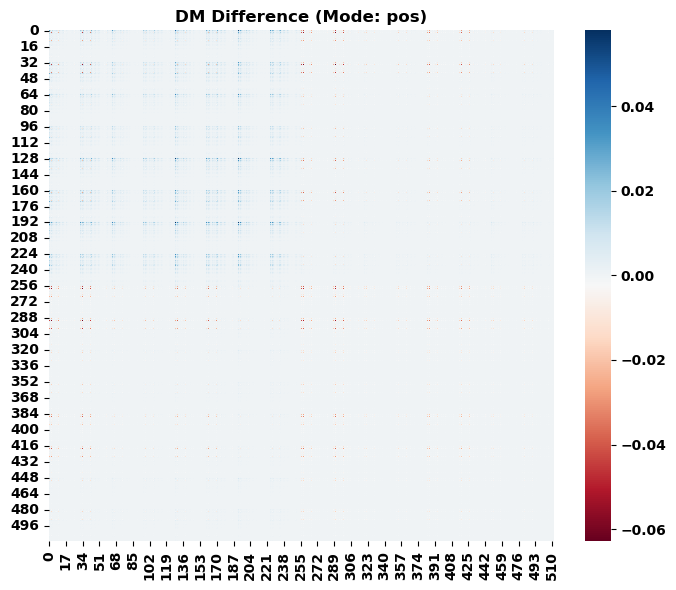


--- CNOT Analysis (pos) ---
Max Signal: 0.0580
Candidates Found: 40 / 72
------------------------------

Initial KL Divergence (no CNOTs): 0.922691

--- Building KL Divergence Matrix (40x40) ---
Calculating KL for single CNOTs (diagonal elements)...
Calculating KL for CNOT pairs (off-diagonal elements)...
Total CNOT pairs tested: 1560
--- KL Divergence Matrix Built ---


In [22]:
from quantum_functions import build_kl_divergence_matrix_interaction

thresh = 0.01
np.random.seed(42) 

print("\n" + "="*40)
print("--- Creating QUBO matrix ---")
print("="*40)

kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum = build_kl_divergence_matrix_interaction(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh, 
    search_mode= "pos",
    include_single_cnot_kl=True
)

In [23]:
from quantum_functions import kl_to_qubo_matrix

# Creating Q matrix 
kl_div_mat_qubo = kl_to_qubo_matrix(kl_matrix = kl_divergence_matrix, initial_kl_sum = initial_kl_sum)

In [24]:
from qiskit_optimization import QuadraticProgram
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# Assume kl_div_mat_qubo is your 42x42 NumPy array

num_qubits = kl_div_mat_qubo.shape[0]

# --- 1. Define the Quadratic Program (QUBO) ---
qp = QuadraticProgram(name="CnotOptimization")

for i in range(num_qubits):
    qp.binary_var(name=f'x{i}')

# Set the objective function to minimize the cost defined by the QUBO matrix
# The matrix must be passed as the 'quadratic' term.
qp.minimize(quadratic=kl_div_mat_qubo)

# --- 2. Convert the QUBO to an Ising Hamiltonian ---
# The Ising Converter performs the necessary transformation (x = (1 - Z)/2)
hamiltonian, offset = qp.to_ising()
print(offset)
print(hamiltonian)

3.9730969889795045
SparsePauliOp(['...'],
              coeffs=[-2.51979560e-01+0.j,  3.74467392e-03+0.j,  2.45223040e-02+0.j,
  1.22350106e-02+0.j, -2.26543630e-01+0.j,  5.97062242e-03+0.j,
 -1.96583513e-01+0.j,  3.71004733e-04+0.j, -6.14578412e-02+0.j,
  4.06843293e-04+0.j, -1.97706826e-01+0.j, -9.88502134e-03+0.j,
 -9.78032439e-02+0.j,  4.30878683e-03+0.j,  8.83944243e-03+0.j,
  7.23841432e-03+0.j, -2.86799998e-01+0.j,  4.04695886e-03+0.j,
 -9.44925845e-02+0.j,  1.36979041e-02+0.j, -3.99654100e-01+0.j,
  4.26020973e-03+0.j, -2.17435747e-01+0.j,  7.80171703e-03+0.j,
  5.52270846e-03+0.j,  8.11754967e-03+0.j, -1.24549034e-01+0.j,
  2.07431204e-02+0.j, -4.61441543e-01+0.j,  6.03524045e-03+0.j,
 -2.81756059e-01+0.j,  1.01544273e-02+0.j, -2.92898159e-01+0.j,
  5.08486345e-03+0.j, -2.46077941e-01+0.j,  7.30154766e-03+0.j,
  4.83787137e-02+0.j,  3.40032613e-03+0.j,  1.28398517e-01+0.j,
  4.09588895e-03+0.j, -1.43644126e-01+0.j,  1.40676724e-02+0.j,
 -2.87812029e-01+0.j,  7.93467421e-03+0.j

In [25]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_aer import AerSimulator
from qiskit.circuit.library import EfficientSU2
from qiskit.circuit import QuantumCircuit
from qiskit.compiler import transpile
import numpy as np

# --- 1. Configuration (Example values) ---
num_qubits = kl_div_mat_qubo.shape[0]
reps = 1
entanglement = 'circular'  # linear sca circular pairwise reverse_linear full

# --- 2. Ansatz Creation ---
ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)

basis_gates = ['u', 'cx'] 
# 2. Transpile the circuit to decompose it into the basis gates.
expanded_ansatz = transpile(
    ansatz, 
    basis_gates = basis_gates, 
    optimization_level = 0  # Set to 0 to minimize changes beyond decomposition
)

# To run on hardware, select the backend with the fewest number of jobs in the queue
backend = AerSimulator()
#backend = service.least_busy(operational=True, simulator=False)
#expanded_ansatz.draw()

C:\Users\ssromerogon\AppData\Local\Temp\ipykernel_9872\2260493373.py:14: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)


In [26]:
from quantum_functions import vqe_solver
result, optimized_params, cost_values = vqe_solver(
    expanded_ansatz,
    hamiltonian,
    backend,
    optimizer_method="COBYLA", # COBYLA | L-BFGS-B 
    niter= 200
)

# Plot the cost function values
plt.figure(figsize=(5, 4))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
#plt.savefig('vqe_opt_curve_qmat.svg', bbox_inches='tight')
plt.show()    

Starting optimization with method: COBYLA


Simulation failed and returned the following error message:
ERROR:  [Experiment 0] Insufficient memory to run circuit EfficientSU2-468145 using the statevector simulator. Required memory: 16777216M, max memory: 32456M


QiskitError: 'ERROR:  [Experiment 0] Insufficient memory to run circuit EfficientSU2-468145 using the statevector simulator. Required memory: 16777216M, max memory: 32456M ,  ERROR: Insufficient memory to run circuit EfficientSU2-468145 using the statevector simulator. Required memory: 16777216M, max memory: 32456M'